In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import joblib
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from matplotlib import pyplot as plt


# Path from Notebook 3: CNN-LSTM_preprocessing.ipynb
artifacts = joblib.load('preprocessing_artifacts_CNN_LSTM.pkl')
dynamic_dim = len(artifacts['dynamic_cols'])
static_dim = len(artifacts['static_cols'])

# Load arrays from Feature Engineering Notebook
data = joblib.load('cnn_lstm_data.pkl')
X_dyn_np = data['X_dynamic']
X_stat_np = data['X_static']
y_np = data['y']

# CRITICAL: Robustly handle any NaNs left in the source arrays
X_dyn_np = np.nan_to_num(X_dyn_np, nan=0.0, posinf=0.0, neginf=0.0)
X_stat_np = np.nan_to_num(X_stat_np, nan=0.0, posinf=0.0, neginf=0.0)

# Convert to Tensors
X_dyn_tensor = torch.tensor(X_dyn_np, dtype=torch.float32)
X_stat_tensor = torch.tensor(X_stat_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np[:, -1] if len(y_np.shape) > 1 else y_np, dtype=torch.float32)

# Create Loaders
full_dataset = TensorDataset(X_dyn_tensor, X_stat_tensor, y_tensor)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

In [ ]:
class SepsisCNNLSTM(nn.Module):
    def __init__(self, dynamic_dim, static_dim, lstm_units=64):
        super(SepsisCNNLSTM, self).__init__()
        
        # 1D CNN Branch - Section 2.5.3 of Paper
        self.cnn_branch = nn.Sequential(
            nn.Conv1d(in_channels=dynamic_dim, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), # Essential for stability
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=1, padding=1)
        )
        
        # LSTM Branch
        self.lstm = nn.LSTM(input_size=64, hidden_size=lstm_units, batch_first=True)
        
        # Static Context Branch (Age, Gender, etc.)
        self.static_branch = nn.Linear(static_dim, 16)
        
        # Final Classifier
        self.classifier = nn.Sequential(
            nn.Linear(lstm_units + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1) # Outputs raw Logits for BCEWithLogitsLoss
        )

    def forward(self, dyn, stat):
        x = dyn.transpose(1, 2)
        x = self.cnn_branch(x)
        x = x[:, :, :dyn.size(1)].transpose(1, 2)
        
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        
        stat_out = torch.relu(self.static_branch(stat))
        combined = torch.cat((last_step, stat_out), dim=1)
        return self.classifier(combined)

In [12]:
model = SepsisCNNLSTM(dynamic_dim=dynamic_dim, static_dim=static_dim)

def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv1d):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            m.bias.data.fill_(0.01)

model.apply(init_weights)

# Stable Loss and Optimizer
# criterion = nn.BCEWithLogitsLoss()
pos_weight = torch.tensor([14.0]) 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Slower learning rate for stability


# def train_and_save(model, train_loader, val_loader, epochs=10):
#     best_loss = float('inf')
#     save_path = 'best_sepsis_model.pth'
    
#     for epoch in range(epochs):
#         model.train()
#         train_loss = 0
#         for d, s, t in train_loader:
#             optimizer.zero_grad()
#             logits = model(d, s).squeeze()
#             loss = criterion(logits, t)
            
#             if torch.isnan(loss): continue # Skip corrupted gradients
                
#             loss.backward()
#             # CLIPPING: Limits gradient size to prevent NaNs
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()
#             train_loss += loss.item()
            
#         model.eval()
#         val_loss = 0
#         all_preds, all_targets = [], []
        
#         with torch.no_grad():
#             for d, s, t in val_loader:
#                 logits = model(d, s).squeeze()
#                 val_loss += criterion(logits, t).item()
                
#                 # Convert logits to 0-1 probabilities safely
#                 probs = torch.sigmoid(logits).cpu().numpy()
#                 all_preds.extend(probs)
#                 all_targets.extend(t.cpu().numpy())
        
#         # SAFETY CHECK: Filter out NaNs for metric calculation
#         all_preds = np.array(all_preds)
#         all_targets = np.array(all_targets)
#         mask = ~np.isnan(all_preds)
        
#         if np.any(mask):
#             auc = roc_auc_score(all_targets[mask], all_preds[mask])
#             avg_v = val_loss / len(val_loader)
#             print(f"Epoch {epoch+1}: Val Loss={avg_v:.4f} | AUROC={auc:.4f}")
            
#             if avg_v < best_loss:
#                 best_loss = avg_v
#                 torch.save(model.state_dict(), save_path)
#                 print(f"--> Saved stable model to {save_path}")
#         else:
#             print(f"Epoch {epoch+1}: Critical Failure. Model produced only NaNs.")



def train_and_save(model, train_loader, val_loader, epochs=50, patience=7):
    best_loss = float('inf')
    save_path = 'best_sepsis_model.pth'
    
    # Early Stopping variables
    epochs_no_improve = 0
    early_stop = False
    
    # Lists to store history for plotting later
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        
        for d, s, t in train_loader:
            optimizer.zero_grad()
            logits = model(d, s).squeeze()
            loss = criterion(logits, t)
            
            if torch.isnan(loss): continue
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_train_loss += loss.item()
            
        avg_train_loss = running_train_loss / len(train_loader)
            
        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        all_preds, all_targets = [], []
        
        with torch.no_grad():
            for d, s, t in val_loader:
                logits = model(d, s).squeeze()
                v_loss = criterion(logits, t)
                
                running_val_loss += v_loss.item()
                
                probs = torch.sigmoid(logits).cpu().numpy()
                all_preds.extend(probs)
                all_targets.extend(t.cpu().numpy())
        
        avg_val_loss = running_val_loss / len(val_loader)
        
        # Calculate AUC safely
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        mask = ~np.isnan(all_preds)
        auc = roc_auc_score(all_targets[mask], all_preds[mask]) if np.any(mask) else 0
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_auc'].append(auc)

        # OUTPUT: Print both losses and metrics
        print(f"Epoch {epoch+1}/{epochs} -> "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val AUROC: {auc:.4f}")
            
        # --- EARLY STOPPING LOGIC ---
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  --> Lowest Val Loss found. Model saved to {save_path}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  --> No improvement for {epochs_no_improve} epoch(s).")
            
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break
            
    return history

# Run training
history = train_and_save(model, train_loader, val_loader, epochs=50, patience=7)

Epoch 1/50 -> Train Loss: 1.0170 | Val Loss: 0.9923 | Val AUROC: 0.8478
  --> Lowest Val Loss found. Model saved to best_sepsis_model.pth
Epoch 2/50 -> Train Loss: 0.8815 | Val Loss: 0.8194 | Val AUROC: 0.8642
  --> Lowest Val Loss found. Model saved to best_sepsis_model.pth
Epoch 3/50 -> Train Loss: 0.8684 | Val Loss: 1.0194 | Val AUROC: 0.8714
  --> No improvement for 1 epoch(s).
Epoch 4/50 -> Train Loss: 0.8452 | Val Loss: 0.8608 | Val AUROC: 0.8835
  --> No improvement for 2 epoch(s).
Epoch 5/50 -> Train Loss: 0.8168 | Val Loss: 0.9579 | Val AUROC: 0.8854
  --> No improvement for 3 epoch(s).
Epoch 6/50 -> Train Loss: 0.8102 | Val Loss: 0.7990 | Val AUROC: 0.8871
  --> Lowest Val Loss found. Model saved to best_sepsis_model.pth
Epoch 7/50 -> Train Loss: 0.7849 | Val Loss: 0.8451 | Val AUROC: 0.8851
  --> No improvement for 1 epoch(s).
Epoch 8/50 -> Train Loss: 0.7733 | Val Loss: 1.0797 | Val AUROC: 0.8860
  --> No improvement for 2 epoch(s).
Epoch 9/50 -> Train Loss: 0.7507 | Val Lo

In [13]:
# Load best weights for final use
model.load_state_dict(torch.load('best_sepsis_model.pth'))
print("Training complete. Best weights loaded.")

Training complete. Best weights loaded.


Evaluating best model...

      FINAL PERFORMANCE
AUROC:     0.8871
F1-Score:  0.4764
Precision: 0.4118
Recall:    0.5650

Detailed Report:
              precision    recall  f1-score   support

   No Sepsis       0.97      0.95      0.96      7622
      Sepsis       0.41      0.57      0.48       446

    accuracy                           0.93      8068
   macro avg       0.69      0.76      0.72      8068
weighted avg       0.94      0.93      0.94      8068



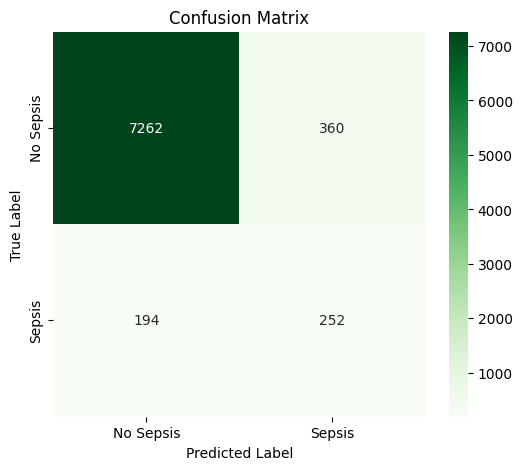

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns

def final_evaluation(model, val_loader, model_path='best_sepsis_model.pth'):
    # 1. Load the best saved weights
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    all_probs = []
    all_preds = []
    all_targets = []
    
    print("Evaluating best model...")
    with torch.no_grad():
        for d, s, t in val_loader:
            logits = model(d, s).squeeze()
            probs = torch.sigmoid(logits).cpu().numpy()
            
            # Use 0.5 as the decision threshold for binary classification
            binary_preds = (probs >= 0.5).astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(binary_preds)
            all_targets.extend(t.cpu().numpy())

    # 2. Calculate Metrics
    precision = precision_score(all_targets, all_preds, zero_division=0)
    recall = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    auroc = roc_auc_score(all_targets, all_probs)

    # 3. Print Summary Table
    print("\n" + "="*30)
    print("      FINAL PERFORMANCE")
    print("="*30)
    print(f"AUROC:     {auroc:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print("="*30)

    # 4. Detailed Classification Report
    print("\nDetailed Report:")
    print(classification_report(all_targets, all_preds, target_names=['No Sepsis', 'Sepsis']))

    # 5. Visual Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['No Sepsis', 'Sepsis'], 
                yticklabels=['No Sepsis', 'Sepsis'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Execute the evaluation
final_evaluation(model, val_loader)

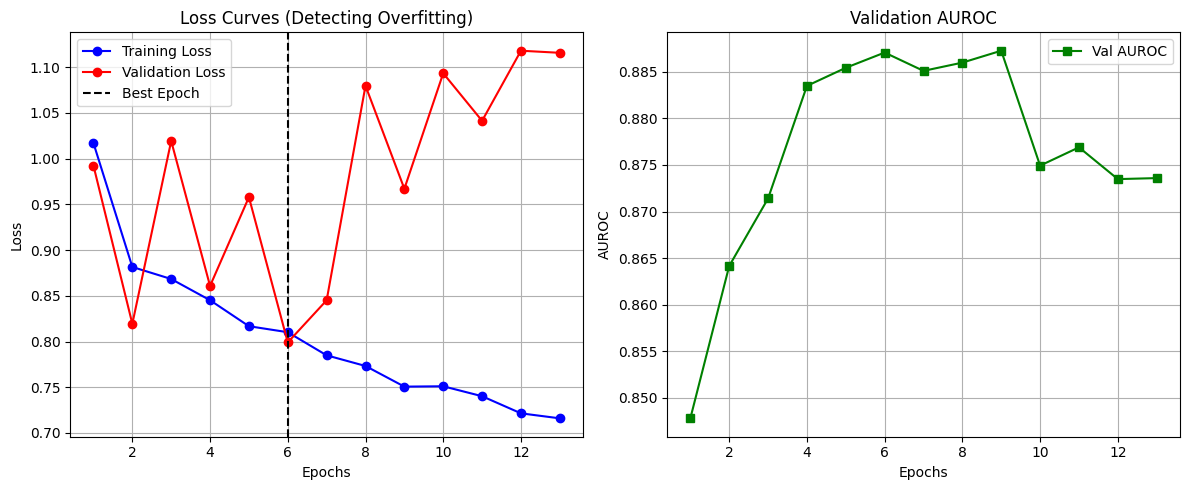

In [15]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-o', label='Validation Loss')
    plt.axvline(x=np.argmin(history['val_loss'])+1, color='k', linestyle='--', label='Best Epoch')
    plt.title('Loss Curves (Detecting Overfitting)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # AUROC Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_auc'], 'g-s', label='Val AUROC')
    plt.title('Validation AUROC')
    plt.xlabel('Epochs')
    plt.ylabel('AUROC')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Run the plot
plot_learning_curves(history)

C:\Users\nour1\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


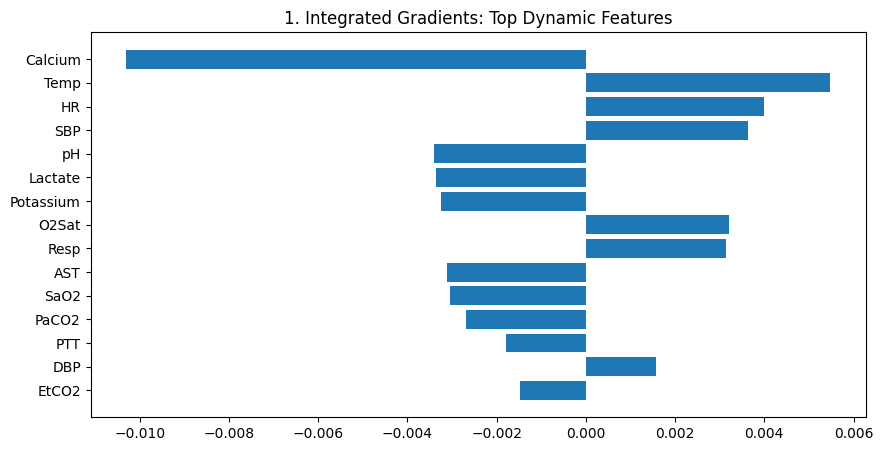

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients

# 0. Prepare samples
model.eval()
data_iter = iter(val_loader)
batch = next(data_iter)
d_input, s_input, labels = batch[0], batch[1], batch[2]

# Integrated Gradients (Overall Feature Importance) ---
# Purpose: Which clinical features drive the prediction?
ig = IntegratedGradients(model)
# Note: Inputs must be a tuple for multi-input models
attr_dyn, attr_stat = ig.attribute(inputs=(d_input, s_input), target=0)

avg_dyn_attr = attr_dyn.mean(dim=0).mean(dim=0).detach().numpy() # Avg across batch and time
feat_names = artifacts['dynamic_cols']

plt.figure(figsize=(10, 5))
indices = np.argsort(np.abs(avg_dyn_attr))[-15:] # Top 15
plt.barh(range(len(indices)), avg_dyn_attr[indices])
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.title("1. Integrated Gradients: Top Dynamic Features")
plt.show()

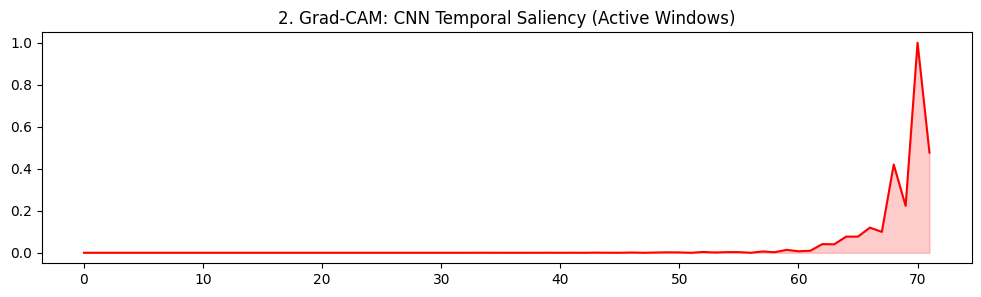

In [17]:
# Grad-CAM (CNN Branch/Local Patterns) ---
# Purpose: Which specific 5-minute/hourly blocks did the CNN identify as "Sepsis-like"?
feature_grads = []
def save_grad(grad): feature_grads.append(grad)

# Register hook on the last layer of the CNN branch (BatchNorm or ReLU)
handle = model.cnn_branch[4].register_full_backward_hook(lambda m, gi, go: save_grad(go[0]))

out = model(d_input[0:1], s_input[0:1])
model.zero_grad()
out.backward()

# Calculate Heatmap
grads = feature_grads[0].cpu().data.numpy()
weights = np.mean(grads, axis=2)
cam = np.maximum(np.zeros(grads.shape[2]), np.sum(weights[0, :, None] * grads[0], axis=0))
cam = cam / (np.max(cam) + 1e-10)

plt.figure(figsize=(12, 3))
plt.plot(cam, color='red')
plt.fill_between(range(len(cam)), cam, color='red', alpha=0.2)
plt.title("2. Grad-CAM: CNN Temporal Saliency (Active Windows)")
plt.show()
handle.remove()

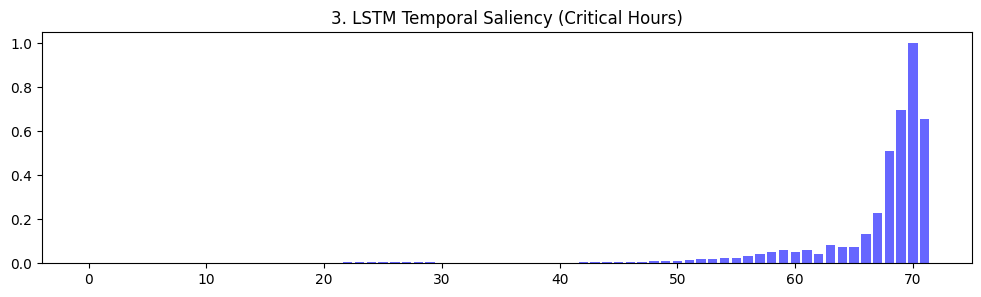

In [18]:
#LSTM Temporal Saliency ---
# Purpose: When in the sequence is the model most sensitive to changes?
d_input_v = d_input[0:1].clone().detach().requires_grad_(True)
out = model(d_input_v, s_input[0:1])
out.backward()
# Saliency is the absolute gradient of the output w.r.t the input
saliency = d_input_v.grad.abs().sum(dim=-1).squeeze().numpy()
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-10)

plt.figure(figsize=(12, 3))
plt.bar(range(len(saliency)), saliency, color='blue', alpha=0.6)
plt.title("3. LSTM Temporal Saliency (Critical Hours)")
plt.show()

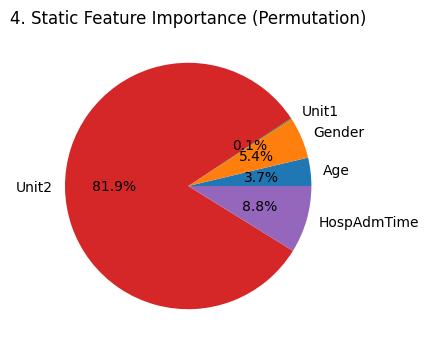

In [19]:

# --- TECHNIQUE 4: Permutation Importance (Static Branch) ---
# Purpose: How much do baseline factors (Age, Gender) impact the score?
baseline_out = torch.sigmoid(model(d_input, s_input)).mean().item()
static_importance = []
s_names = artifacts['static_cols']

for i in range(len(s_names)):
    s_permuted = s_input.clone()
    s_permuted[:, i] = s_permuted[torch.randperm(s_permuted.size(0)), i] # Shuffle one feature
    perm_out = torch.sigmoid(model(d_input, s_permuted)).mean().item()
    static_importance.append(abs(baseline_out - perm_out))

plt.figure(figsize=(8, 4))
plt.pie(static_importance, labels=s_names, autopct='%1.1f%%')
plt.title("4. Static Feature Importance (Permutation)")
plt.show()

In [22]:
import shap
import numpy as np
from lime import lime_tabular

# 1. Prepare Data for SHAP/LIME
# We use the validation set to explain predictions
model.eval()
# We flatten the dynamic features for LIME/SHAP compatibility (Time * Features)
X_dyn_val = X_dyn_tensor.numpy()
X_stat_val = X_stat_tensor.numpy()

Running LIME for a single patient...
LIME Explanation for Patient 0:


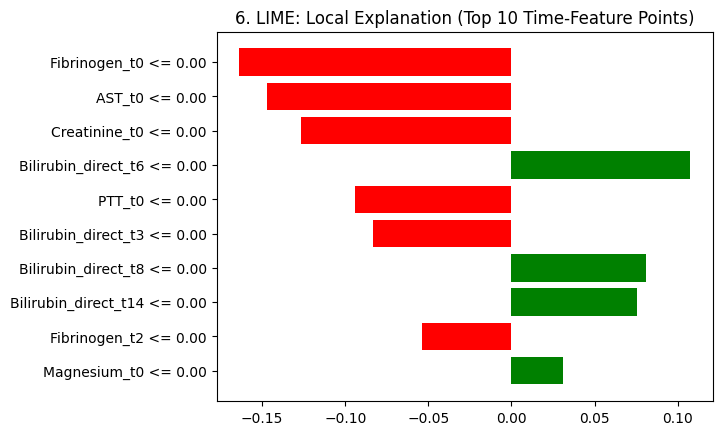

In [23]:
# 3. LIME (Local Interpretable Model-agnostic Explanations)
# Purpose: Explaining a SINGLE patient's prediction by perturbing their data
print("Running LIME for a single patient...")

# Define a prediction function that LIME can call
def lime_predict(x_flattened):
    # LIME sends flattened data, we must reshape it back to (Batch, Time, Features)
    # This assumes we are explaining the dynamic features only for this view
    batch_size = x_flattened.shape[0]
    time_steps = 72
    num_feats = dynamic_dim
    
    x_reshaped = torch.tensor(x_flattened.reshape(batch_size, time_steps, num_feats), dtype=torch.float32)
    # We provide a fixed static context (e.g., from the first patient) for the LIME perturbation
    stat_fixed = X_stat_tensor[0:1].repeat(batch_size, 1)
    
    with torch.no_grad():
        logits = model(x_reshaped, stat_fixed)
        probs = torch.sigmoid(logits).numpy()
    
    # LIME expects probabilities for [Class 0, Class 1]
    return np.hstack([1-probs, probs])

# Flatten the time-series for the explainer
X_dyn_flat = X_dyn_np.reshape(X_dyn_np.shape[0], -1)
feature_names_flat = [f"{col}_t{t}" for t in range(72) for col in artifacts['dynamic_cols']]

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_dyn_flat,
    feature_names=feature_names_flat,
    class_names=['No Sepsis', 'Sepsis'],
    mode='classification'
)

# Explain the first patient in the validation set
idx_to_explain = 0
exp = lime_explainer.explain_instance(
    X_dyn_flat[idx_to_explain], 
    lime_predict, 
    num_features=10
)

print(f"LIME Explanation for Patient {idx_to_explain}:")
exp.as_pyplot_figure()
plt.title("6. LIME: Local Explanation (Top 10 Time-Feature Points)")
plt.show()